In [12]:
from datasets import load_dataset  
import numpy as np  

In [13]:
ds = load_dataset("imdb")

In [14]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [15]:
train_df = ds["train"].to_pandas()

In [19]:
train_df.sample(10)

,text,label
7003,An interesting idea (four African American wom...,0
8067,The most ridiculous thing about this ridiculou...,0
8149,"Seriously, Why do American and Frech actors pr...",0
4803,I love John Saxon in anything he's in. The one...,0
15987,"I just want to add my two cents worth, and for...",1
12718,One of my favorite scenes is at the beginning ...,1
13915,I'm a writer working at home and Diagnosis Mur...,1
16794,"One of my favourite ""domestic"" movies. I don't...",1
19037,"mahatma Gandhi, the father of the nation in hi...",1
17503,This is my FAVORITE ALL time movie. It used to...,1


In [20]:
train_df.sentiment.value_counts()

AttributeError: 'DataFrame' object has no attribute 'sentiment'

In [21]:
train_df['label'].value_counts()


label
0    12500
1    12500
Name: count, dtype: int64

In [22]:
train_df['sentiment']= np.where(train_df.label==1, 'positive', 'negative')

<Axes: >

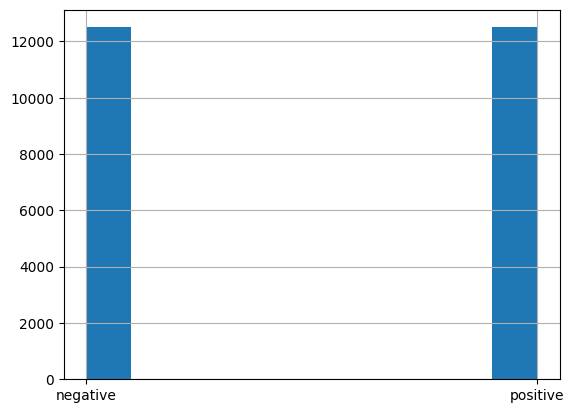

In [23]:
train_df.sentiment.hist()

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
example_df, gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=123)

In [26]:
example_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [ ]:
gold_examples = (gold_examples_df[columns]
.sample(20, random_state=63)
.to_json(orient='records'))

In [28]:
import json

In [29]:
json.loads(gold_examples)


[{'text': "Steve Carpenter cannot make horror movies. First of all, the casting was very wrong for this movie. The only decent part was the hot brown haired girl from Buffy the Vampire Slayer. This movies has no gore(usually a key ingredient to a horror movie), no action, no acting, and no suspense(also a key ingredient). Wes Bentley is a good actor but he is so dry and plain in this that it's sad. There were a few parts that were supposed to be funny(continuing the teen horror/comedy movies) and no one laughed in the audience. I thought that this movie was rated R, and I didn't pay attention and realized it had been changed to PG-13. Anyway, see this movie if you liked I Still Know What You Did Last Summer. That's the only type of person who would find this movie even remotely scary. And seriously, this is to you Steve Carpenter, stop making horror movies. This movie makes Scream look like Texas Chainsaw Massacre.",
  'sentiment': 'negative'},
 {'text': "It's a waist to indulge such g

In [30]:
user_prompt_template = """ '''{movie_review}'''  """

In [31]:
zero_shot_prompt_system = """  
classify the sentiment of the following movie review as either positive or negative.
miie review will be delimited by triple backticks.'''in the input answer only as 'positive or 'negative'
do not edxplain your answer, only return the sentiment.
"""

In [32]:
zero_shot_prompt =[{ "role": "system", "content": zero_shot_prompt_system }]

In [33]:
few_shot_prompt_system = """  
classify the sentiment of the following movie review as either positive or negative.
miie review will be delimited by triple backticks.'''in the input answer only as 'positive or 'negative'
do not edxplain your answer, only return the sentiment.
"""

In [34]:
example_df

,text,label,sentiment
9064,Ulises is a literature teacher that arrives to...,0,negative
6051,Tarzan the Ape Man is a remake of the 1932 fil...,0,negative
17848,This movie is great! This movie is beautiful! ...,1,positive
5408,"Typical Troma-trash, this smutty 80's flick is...",0,negative
18025,Roman Polanski masterfully directs this sort o...,1,positive
...,...,...,...
15377,Cinderella was one of the first movies I ever ...,1,positive
21602,Dev Anand (or Prashant) and Zeenat Aman ( Jasb...,1,positive
17730,"Interesting, fast-paced and amusing.<br /><br ...",1,positive
15725,Perhaps the most polished and accomplished of ...,1,positive


In [35]:
example_df.shape

(20000, 3)

In [50]:
positive_reviews_df=(example_df[example_df['sentiment']=='positive'][columns]
.sample(4))

In [41]:
positive_reviews_df

,text,label,sentiment
24586,"Antonio Margheriti's ""Danza Macabra"" aka. ""Cas...",1,positive
12738,"Sequel to ""The Kingdom"" is bloodier and even m...",1,positive
24205,Those who love Elivra as I did in her late nig...,1,positive
13538,"It's very very funny. You know, just like a co...",1,positive


In [49]:
negative_reviews_df =(example_df[example_df['sentiment']=='negative'][columns]
                      .sample(4))

In [43]:
negative_reviews_df

,text,label,sentiment
2885,This movie start quite gruesomely with a femal...,0,negative
439,Add to the list of caricatures: a Southern pre...,0,negative
9866,"""Problem Child"" is one of the goofiest movies ...",0,negative
4068,'1408' is the latest hodge podge of cheap scar...,0,negative


In [51]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [45]:
positive_examples=(positive_reviews_df[columns]
                   .sample(4)
                   .to_json(orient='records'))

In [46]:
positive_examples

'[{"text":"Antonio Margheriti\'s \\"Danza Macabra\\" aka. \\"Castle Of Blood\\" of 1964 is a beautiful and incredibly haunting masterpiece of Italian Gothic Horror, and after Mario Bava\'s \\"La Maschera Del Demonio\\" (aka. \\"Black Sunday\\") of 1960 and Roger Corman\'s \\"Pit And The Pendulum\\" of 1961 (starring the great Vincent Price) another must-see that earned the wonderful Barbara Steele her more than deserved fame as the most important female Horror icon in the history of motion pictures. But not only is the beautiful and brilliant Barbara Steele one of my favorite actresses of all-time, the screenplay to \\"Danza Macabra\\" was co-written by no one less than the cinematic genius Sergio Corbucci, who directed such ingenious Spaghetti Western milestones as \\"Django\\" (1966) and \\"The Great Silence\\" (1968). Italy\'s number 2 in the field (right after Mario Bava), Director Antonio Margheriti is one of the all-time masters of Gothic Horror, and \\"Castle of Blood\\" is doub

In [47]:
negative_examples=(negative_reviews_df[columns].sample(4).to_json(orient='records'))

In [48]:
negative_examples

'[{"text":"Add to the list of caricatures: a Southern preacher and \\"congregation,\\" a torch singer (Sophie Tucker?), a dancing chorus, and The Mills Brothers -- it only makes it worse.<br \\/><br \\/>Contemptible burlesques of \\"Negro\\" performers, who themselves often appear in films to be parodying themselves and their race. Though the \\"Negro comedy\\" may have been accepted in its day, it\'s extremely offensive today, and I doubt that it was ever funny. Though I wouldn\'t have been offended, I don\'t think that I\'d have laughed at the feeble attempts at humor. As an 11-year-old white boy, however, I might not have understood some of it.","sentiment":"negative"},{"text":"\\"Problem Child\\" is one of the goofiest movies ever made. It\'s not the worst (though some people will disagree with me on that), but it\'s not the best either. It\'s about a devilish 7-year-old boy who wrecks comic havoc on a childless couple (John Ritter, Amy Yasbeck) who foolishly adopts him. This film 

In [61]:
import pandas as pd

In [62]:
examples_df= pd.concat(
    [positive_reviews_df, negative_reviews_df])

In [63]:
examples_df


,text,sentiment
18037,I can understand how fans of filmmaker Roman P...,positive
13280,"I settled back to watch ""Read My Lips,"" a plat...",positive
18598,I enjoyed this movie so much that I watched it...,positive
20576,This would have been so much fun to see in a t...,positive
6733,I saw this move several years ago at the Centr...,negative
1280,"After Life is a Miracle, I did not expect much...",negative
2589,"Watching CBS's ""Surrender, Dorothy"", I kept wo...",negative
5567,Dolph Lundgren stars as a former cop/boxer who...,negative


In [69]:
examples = examples_df.sample(4*2 , replace=False).to_json(orient='records')

In [71]:
json.loads(examples)

[{'text': "I can understand how fans of filmmaker Roman Polanski could love this movie- and I could understand how some could totally hate it (Ebert was one of the few who couldn't understand why people weren't running out of the theater). After a first viewing, I'm not sure I could fall into either category, however as someone who can't get enough of Kafka and bizarre dark comedies of paranoia The Tenant is effective enough for its running time. Or maybe not- this is one of those cases where it might have been more of a masterwork if it were a half-hour Twilight Zone episode, with Serling delivering the coda as Terkovsky (or whomever it might be(?)) writhes in his bed in bandages. It's very similar in the treatment of the doomed protagonist as Repulsion was, however it could be argued that there was more ambiguity, more of a sense of the surreal coming out through a sustained disintegration of character and location (and, quite frankly, a better lead performance) than the Tenant.<br /

In [72]:
def create_examples(dataset, n=4):
    positive_reviews_df=(dataset[dataset['sentiment']=='positive'][columns]
.sample(n)
)
    negative_reviews_df =(dataset[dataset['sentiment']=='negative'][columns]
.sample(n)
                      )
    
    examples_df= pd.concat(
    [positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(n*2 , replace=False).to_json(orient='records')
    return examples


In [82]:
few_shot_examples=create_examples(example_df, n=2)

In [81]:
json.loads(examples)

[{'text': 'Samuel Fuller is an interesting filmmaker, mainly because he had some very inconsistent politics in his films. While "Shock Corridor" and "The Naked Kiss" represented the hypocrisies and lunacy of America and "The Big Red One" was an effective portrait of the horrors of war, "Merrill\'s Marauders" painted war as necessary hell and "Pickup on South Street" is about the dangers of communist spies. All of his films make for very entertaining viewing, and even though he was often pigeonholed as a b-filmmaker, Fuller was just as good as any of the major studio contractors. "Pickup on South Street" is no exception, and despite the dated themes, the film-making style is remarkably ahead of its time. Its also a very quickly-pace, tight, and occasionally brutal film noir.<br /><br />The acting across the board is fantastic. Richard Widmark makes for a great anti-hero and Jean Peters is quite sexy as a girl who works for her communist spy boyfriend. The show stealer is Thlema Ritter h

In [86]:
def create_prompts(system_message,examples,user_prompt_template):
    prompt = [
        {"role": "system", "content": system_message}]
    for example in json.loads(examples):
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        prompt.append({"role": "assistant", "content": sentiment})
    return prompt

In [87]:
few_shot_prompt = create_prompts(few_shot_prompt_system,few_shot_examples,user_prompt_template)

In [88]:
few_shot_prompt

[{'role': 'system',
  'content': "  \nclassify the sentiment of the following movie review as either positive or negative.\nmiie review will be delimited by triple backticks.'''in the input answer only as 'positive or 'negative'\ndo not edxplain your answer, only return the sentiment.\n"},
 {'role': 'user',
  'content': " '''Some fraud girl tries to compete in the big leagues of motorcross by swiching places with her brother. She gets to the top by lying and manipulation. She should have been disqualified. The movie promotes lying and cheating to win. also the idea of a 9 yr old mechanic is absurd. it takes many many years to get good. Go back to the tonka toys.'''  "},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': ' \'\'\'Philo Vance had many affinities with Bulldog Drummond\x85 He was a gentleman with the kind of polish and elegance only usually associated with the British upper classes and he was also independently wealthy\x85<br /><br />But there wer

In [90]:
cot_few_shot_prompt_system = """  
classify the sentiment of the following movie review as either positive or negative.
miie review will be delimited by triple backticks.'''in the input answer only as 'positive or 'negative'
do not edxplain your answer, only return the sentiment.

Instructions:
1. read the movie review and classify its sentiment as either positive or negative.
2. consider the overall sentiment of the review and estimate the probability of the review being positive or negative your answer should strictly follow the format: 'positive' or 'negative' 
"""

In [95]:
cot_few_shot_prompt= create_prompts(few_shot_prompt_system,
                                           few_shot_examples,
                                           user_prompt_template)

In [97]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "  \nclassify the sentiment of the following movie review as either positive or negative.\nmiie review will be delimited by triple backticks.'''in the input answer only as 'positive or 'negative'\ndo not edxplain your answer, only return the sentiment.\n"},
 {'role': 'user',
  'content': " '''Some fraud girl tries to compete in the big leagues of motorcross by swiching places with her brother. She gets to the top by lying and manipulation. She should have been disqualified. The movie promotes lying and cheating to win. also the idea of a 9 yr old mechanic is absurd. it takes many many years to get good. Go back to the tonka toys.'''  "},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': ' \'\'\'Philo Vance had many affinities with Bulldog Drummond\x85 He was a gentleman with the kind of polish and elegance only usually associated with the British upper classes and he was also independently wealthy\x85<br /><br />But there wer

In [99]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [108]:
def evaluate_prompts(prompts, gold_examples, user_prompt_template,llm):
    predicted_sentiments = []
    ground_truths_sentiments =  []
    for example in json.loads(gold_examples):
        review = example['text']
        sentiment = example['sentiment']
        user_input = [{"role": "user", "content": user_prompt_template.format(movie_review=review)}]
      
        try: 
           resp = llm.invoke(prompts + user_input)
           if 'negative' in resp.content.strip().lower():
            predicted = 'negative'
           elif 'positive' in resp.content.strip().lower():
               predicted = 'positive'
           else:
            predicted = 'unknown'
            predicted_sentiments.append(predicted)
            ground_truths_sentiments.append(sentiment)
            print(predicted, sentiment)
        except Exception as e:
          print(f"Error processing review: {e}")
          continue
    return f1_score(ground_truths_sentiments, predicted_sentiments, average='macro')


In [102]:
from dotenv.ipython import load_dotenv

In [110]:
load_dotenv(override=True)

True

In [111]:
from langchain_openai import ChatOpenAI 

In [112]:
llm1 = ChatOpenAI(model="gpt-4o", temperature=0)

In [113]:
evaluate_prompts(zero_shot_prompt, gold_examples, user_prompt_template,llm1)

Error processing review: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Error processing review: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Error processing review: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-******************************************

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [114]:
evaluate_prompts(few_shot_prompt, gold_examples, user_prompt_template,llm1)

Error processing review: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Error processing review: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Error processing review: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-******************************************

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [ ]:
evaluate_prompts(cot_few_shot_prompt, gold_examples, user_prompt_template,llm1)

In [115]:
from langchain_ollama import ChatOllama

In [116]:
llm2 = ChatOllama(model="llama3.2", temperature=0)

In [118]:
evaluate_prompts(zero_shot_prompt, gold_examples, user_prompt_template,llm2)


ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [ ]:
evaluate_prompts(few_shot_prompt, gold_examples, user_prompt_template,llm2)


In [ ]:
from tqdm import tqdm

In [ ]:
num_eval_runs = 10
performances = []
for i in tqdm(range(num_eval_runs)):
    examples = create_examples(example_df, n=4)
    fsp=create_prompts(few_shot_prompt_system, examples, user_prompt_template)
    score= evaluate_prompts(fsp, gold_examples, user_prompt_template,llm2)
    performances.append(score)

mean= np.array(performances).mean()
std = np.array(performances).std()
print(f"Mean: {mean}, Std: {std}")